In [1]:
import os
import cv2
import time
import torch
import numpy as np
from pathlib import Path

from ultralytics import YOLO

from anomalib.models import Padim
from anomalib.engine import Engine
from anomalib.data import PredictDataset

from PIL import Image
import matplotlib.pyplot as plt
import tempfile


W0804 20:40:07.089000 19620 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
d:\Projects\VisionXM\.visionXM\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ===========================
# CONFIGURATION
# ===========================

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

YOLO_MODEL_PATH = PROJECT_ROOT / "models" / "yolo_screw_detector" / "weights" / "best.pt"

PADIM_CHECKPOINT = PROJECT_ROOT / "checkpoints" / "padim_checkpoint.ckpt"

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

# FIX: this was defined here AND redefined with a different value later in
# the notebook (0.60 vs 0.50). Kept as the single source of truth now.
ANOMALY_THRESHOLD = 0.60

CONFIDENCE = 0.40

IMG_SIZE = 640

print("Project Root :", PROJECT_ROOT)
print("Device       :", DEVICE)
print("YOLO Model   :", YOLO_MODEL_PATH)
print("PaDiM Model  :", PADIM_CHECKPOINT)


Project Root : d:\Projects\VisionXM
Device       : cuda
YOLO Model   : d:\Projects\VisionXM\models\yolo_screw_detector\weights\best.pt
PaDiM Model  : d:\Projects\VisionXM\checkpoints\padim_checkpoint.ckpt


In [3]:
print("Loading YOLO detector...")

detector = YOLO(str(YOLO_MODEL_PATH))

print("YOLO loaded successfully.")

Loading YOLO detector...
YOLO loaded successfully.


In [4]:
# FIX: the original cell manually loaded the checkpoint with torch.load()
# and hand-rewrote state_dict keys (stripping a "model." prefix) to force
# them onto the Padim module. This is fragile and breaks across anomalib/
# lightning versions. Instead we just build the model architecture here and
# let anomalib's Engine load the checkpoint properly at predict time via
# ckpt_path -- exactly like notebook 1 already does successfully.

print("Building PaDiM model architecture...")

padim = Padim(
    backbone="resnet18",
    layers=["layer1", "layer2", "layer3"],
)

assert PADIM_CHECKPOINT.exists(), f"PaDiM checkpoint not found: {PADIM_CHECKPOINT}\n(Run 001_Screw_Anamoly_Prediction.ipynb first.)"

print("Model ready. Weights will be loaded from checkpoint at inference time.")


Building PaDiM model architecture...


Model ready. Weights will be loaded from checkpoint at inference time.


In [5]:
print("Creating inference engine...")

engine = Engine()

print("Engine ready.")

Creating inference engine...
Engine ready.


In [6]:
def classify_crop(crop):
    """
    Predict whether a cropped screw is Good or Defective using PaDiM.
    """
    with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tmp:
        temp_path = tmp.name

    cv2.imwrite(temp_path, crop)

    dataset = PredictDataset(path=temp_path)

    predictions = engine.predict(
        model=padim,
        dataset=dataset,
        ckpt_path=str(PADIM_CHECKPOINT),
    )

    prediction = predictions[0]
    score = float(prediction.pred_score)

    label = "Defective" if score > ANOMALY_THRESHOLD else "Good"
    color = (0, 0, 255) if label == "Defective" else (0, 255, 0)

    os.remove(temp_path)

    return label, score, color


In [7]:
# Quick smoke test of the classification function on a known-good image
sample_path = DATA_DIR / "train" / "good" / "007.png"
sample_img = cv2.imread(str(sample_path))
assert sample_img is not None, f"Could not read image: {sample_path}"

label, score, color = classify_crop(sample_img)
print("Label:", label)
print("Score:", score)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer(val_check_interval=1.0)` was configured so validation will run at the end of the training epoch..
You are using a CUDA device ('NVIDIA GeForce RTX 5070 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Restoring states from the checkpoint path at D:\Projects\VisionXM\checkpoints\padim_checkpoint.ckpt
d:\Projects\VisionXM\.visionXM\lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:566: The di

d:\Projects\VisionXM\.visionXM\lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

d:\Projects\VisionXM\.visionXM\lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
d:\Projects\VisionXM\.visionXM\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Label: Good
Score: 0.24097153544425964


In [8]:
# (Removed: this used to redundantly redefine the checkpoint path with a
# second, relative CHECKPOINT_DIR variable. PADIM_CHECKPOINT from the config
# cell above is the single source of truth.)


In [9]:
# Optional diagnostic: inspect the raw checkpoint contents.
ckpt = torch.load(PADIM_CHECKPOINT, map_location="cpu")
print(type(ckpt))
print(list(ckpt.keys()))


<class 'dict'>
['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'loops', 'callbacks', 'optimizer_states', 'lr_schedulers', 'hparams_name', 'hyper_parameters']


In [10]:
for key in ckpt["state_dict"].keys():
    print(key)


_is_fitted
post_processor._image_threshold
post_processor._pixel_threshold
post_processor.image_min
post_processor.image_max
post_processor.pixel_min
post_processor.pixel_max
model.idx
model.feature_extractor.feature_extractor.conv1.weight
model.feature_extractor.feature_extractor.bn1.weight
model.feature_extractor.feature_extractor.bn1.bias
model.feature_extractor.feature_extractor.bn1.running_mean
model.feature_extractor.feature_extractor.bn1.running_var
model.feature_extractor.feature_extractor.bn1.num_batches_tracked
model.feature_extractor.feature_extractor.layer1.0.conv1.weight
model.feature_extractor.feature_extractor.layer1.0.bn1.weight
model.feature_extractor.feature_extractor.layer1.0.bn1.bias
model.feature_extractor.feature_extractor.layer1.0.bn1.running_mean
model.feature_extractor.feature_extractor.layer1.0.bn1.running_var
model.feature_extractor.feature_extractor.layer1.0.bn1.num_batches_tracked
model.feature_extractor.feature_extractor.layer1.0.conv2.weight
model.feature

In [11]:
# (Removed: this used to redefine ANOMALY_THRESHOLD=0.50, silently
# overriding the 0.60 set in the config cell above. The config cell is now
# the single source of truth for this value.)


In [12]:
# (Removed: this used to contain a second, broken classify_crop() that
# called `Engine.predict(temp_path)` as a static method, i.e. missing the
# `engine` instance and `model=` argument entirely. That is exactly what
# caused: AttributeError: 'str' object has no attribute 'model'.
# The single, correct classify_crop() is defined above.)


In [13]:
def detect_and_classify(image):
    """
    Run YOLO screw detection, then PaDiM good/defective classification
    on each detected crop. Returns the annotated frame + detection list.
    """
    result = detector(image, conf=CONFIDENCE, imgsz=IMG_SIZE)[0]

    annotated = image.copy()
    detections = []

    for box in result.boxes:

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        crop = image[y1:y2, x1:x2]

        if crop.size == 0:
            continue

        label, score, color = classify_crop(crop)

        cv2.rectangle(
            annotated,
            (x1, y1),
            (x2, y2),
            color,
            2
        )

        cv2.putText(
            annotated,
            f"{label} ({score:.3f})",
            (x1, max(20, y1 - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2
        )

        detections.append({
            "box": [x1, y1, x2, y2],
            "label": label,
            "score": score
        })

    return annotated, detections


In [14]:
# (Removed: this used to be a near-identical duplicate of detect_and_classify()
# defined above -- same logic, defined twice. Only one definition is needed.)



0: 640x640 1 screw, 40.2ms
Speed: 12.3ms preprocess, 40.2ms inference, 7.5ms postprocess per image at shape (1, 3, 640, 640)


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
Restoring states from the checkpoint path at D:\Projects\VisionXM\checkpoints\padim_checkpoint.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at D:\Projects\VisionXM\checkpoints\padim_checkpoint.ckpt


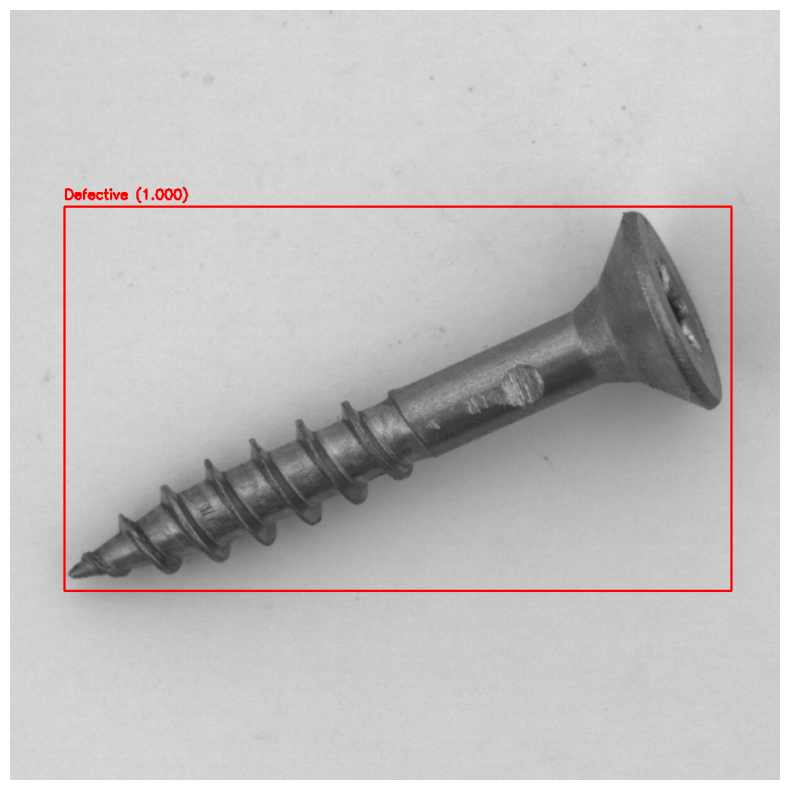

[{'box': [72, 261, 959, 772], 'label': 'Defective', 'score': 1.0}]


In [15]:
IMAGE_PATH = DATA_DIR / "test" / "scratch_neck" / "004.png"

image = cv2.imread(str(IMAGE_PATH))
assert image is not None, f"Could not read image: {IMAGE_PATH}"

result, detections = detect_and_classify(image)

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

print(detections)


In [16]:
# Live webcam inspection loop.
# FIX: added a check that the camera actually opened, and wrapped the loop
# in try/finally so the camera is always released and windows closed even
# if an error occurs mid-loop. Also accept Esc as well as "q" to quit.

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    raise RuntimeError(
        "Could not access the camera (index 0). "
        "Check that a camera is connected and not in use by another app."
    )

try:
    while True:
        ret, frame = cap.read()

        if not ret:
            print("Failed to grab frame from camera.")
            break

        result, _ = detect_and_classify(frame)

        cv2.imshow("YOLO + PaDiM - Screw Inspection", result)

        key = cv2.waitKey(1) & 0xFF
        if key in (ord("q"), 27):  # q or Esc
            break
finally:
    cap.release()
    cv2.destroyAllWindows()



0: 480x640 2 screws, 89.4ms
Speed: 5.2ms preprocess, 89.4ms inference, 6.9ms postprocess per image at shape (1, 3, 480, 640)


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
Restoring states from the checkpoint path at D:\Projects\VisionXM\checkpoints\padim_checkpoint.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at D:\Projects\VisionXM\checkpoints\padim_checkpoint.ckpt


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
Restoring states from the checkpoint path at D:\Projects\VisionXM\checkpoints\padim_checkpoint.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at D:\Projects\VisionXM\checkpoints\padim_checkpoint.ckpt



0: 480x640 2 screws, 28.8ms
Speed: 3.3ms preprocess, 28.8ms inference, 5.9ms postprocess per image at shape (1, 3, 480, 640)


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
Restoring states from the checkpoint path at D:\Projects\VisionXM\checkpoints\padim_checkpoint.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at D:\Projects\VisionXM\checkpoints\padim_checkpoint.ckpt


...

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
Restoring states from the checkpoint path at D:\Projects\VisionXM\checkpoints\padim_checkpoint.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at D:\Projects\VisionXM\checkpoints\padim_checkpoint.ckpt


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
Restoring states from the checkpoint path at D:\Projects\VisionXM\checkpoints\padim_checkpoint.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at D:\Projects\VisionXM\checkpoints\padim_checkpoint.ckpt



0: 480x640 2 screws, 12.8ms
Speed: 2.2ms preprocess, 12.8ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
Restoring states from the checkpoint path at D:\Projects\VisionXM\checkpoints\padim_checkpoint.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at D:\Projects\VisionXM\checkpoints\padim_checkpoint.ckpt


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
Restoring states from the checkpoint path at D:\Projects\VisionXM\checkpoints\padim_checkpoint.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at D:\Projects\VisionXM\checkpoints\padim_checkpoint.ckpt


In [17]:
# Optional: run inspection as an external, always-on script instead of the
# inline loop above (useful outside Jupyter). This is guarded because the
# original notebook referenced a "webcam_screw_inspection.py" file that
# was never included in the project -- running this without that file
# present would just crash.

from pathlib import Path
import subprocess
import sys

script_path = PROJECT_ROOT / "webcam_screw_inspection.py"

if script_path.exists():
    subprocess.run([sys.executable, str(script_path)], check=True)
else:
    print(
        f"Skipping: {script_path} not found.\n"
        "Use the inline webcam loop in the previous cell instead, "
        "or create this script if you want a standalone runner."
    )


CalledProcessError: Command '['d:\\Projects\\VisionXM\\.visionXM\\Scripts\\python.exe', 'd:\\Projects\\VisionXM\\webcam_screw_inspection.py']' returned non-zero exit status 1.